In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from msfm.utils import files, parameters
from msfm.fiducial_pipeline import FiducialPipeline
from msfm.grid_pipeline import GridPipeline

from deep_lss.models.delta_model import DeltaLossModel
from deep_lss.nets import resnet
from deep_lss.utils import utils, distribute, delta_loss

23-06-02 01:01:58    scales.py INF   Setting up healpy to run on 128 CPUs 


### configs

In [2]:
msfm_conf = files.load_config()
dlss_conf = utils.load_deep_lss_config("/global/homes/a/athomsen/y3-deep-lss/configs/delta_loss_debug/dlss_config.yaml")
net_conf = utils.load_deep_lss_config("/global/homes/a/athomsen/y3-deep-lss/configs/resnet_debug.yaml")

# dlss 
params = dlss_conf["dset"]["training"]["params"]
n_params = len(params)

# msfm
data_vec_pix, _, _, _ = files.load_pixel_file(msfm_conf)
n_side = msfm_conf["analysis"]["n_side"]

n_z_bins = 0
if dlss_conf["dset"]["general"]["with_lensing"]:
    n_z_bins += len(msfm_conf["survey"]["metacal"]["z_bins"])
if dlss_conf["dset"]["general"]["with_clustering"]:
    n_z_bins += len(msfm_conf["survey"]["maglim"]["z_bins"])

23-06-02 01:01:59     utils.py INF   Loaded the config 
23-06-02 01:01:59     utils.py INF   Loaded the config 
23-06-02 01:01:59     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 


In [3]:
local_batch_size = 1
global_batch_size = 4 * local_batch_size
checkpoint_dir="/pscratch/sd/a/athomsen/run_files/v3/debug/2023-06-01_04-33-01_resnet_vanilla/checkpoint"
perts = parameters.get_fiducial_perturbations(params)

### training set

In [4]:
fiducial_pipeline = FiducialPipeline(
    conf=msfm_conf,
    with_lensing=False,
    with_clustering=True,
    apply_norm=True,
    params=params,
)
tfr_pattern = "/pscratch/sd/a/athomsen/DESY3/v3/fiducial/DESy3_fiducial_001.tfrecord"

23-06-02 01:01:59     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
23-06-02 01:01:59     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 


2023-06-02 01:02:00.405285: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-06-02 01:02:02.306380: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38218 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:03:00.0, compute capability: 8.0
2023-06-02 01:02:02.308139: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 38218 MB memory:  -> device: 1, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:41:00.0, compute capability: 8.0
2023-06-02 01:02:02.309563: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/devi

### delta loss

In [5]:
general_loss_function = lambda dv_batch, batch_size, strategy: delta_loss.delta_loss(
    predictions=dv_batch,
    n_params=n_params,
    n_same=batch_size,
    off_sets=perts,
    force_params_value=0.0,
    force_params_weight=1.0,
    jac_weight=100.0,
    n_output=n_params,
    tikhonov_regu=False,
    strategy=strategy,
)

# distributed

### model

In [6]:
strategy = distribute.get_strategy(True)

with strategy.scope():
    # load the layers
    network = resnet.ResNetLayers(
        output_shape=n_params, **net_conf["model"]["kwargs"]
    ).get_layers()

    # build the model
    dist_model = DeltaLossModel(
        network=network,
        n_side=n_side,
        indices=data_vec_pix,
        n_neighbors=net_conf["model"]["n_neighbors"],
        max_checkpoints=net_conf["model"]["max_checkpoints"],
        input_shape=(None, len(data_vec_pix), n_z_bins),
        checkpoint_dir=checkpoint_dir,
        summary_dir=None,
        restore_checkpoint=True,
    )
    
dist_model.setup_delta_loss_step(
    n_params,
    local_batch_size,
    perts,
    n_channels=n_z_bins,
    force_params_value=0.0,
    force_params_weight=1.0,
    jac_weight=100.0,
    n_output=n_params,
    tikhonov_regu=False,
    strategy=strategy,
)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1', '/job:localhost/replica:0/task:0/device:GPU:2', '/job:localhost/replica:0/task:0/device:GPU:3')
23-06-02 01:02:03 distribute.p INF   Training is distributed, using MirroredStrategy 
23-06-02 01:02:03 delta_model. INF   Initializing DeltaLossModel with a HealpyGCNN model 
Detected a reduction factor of 32.0, the input with nside 512 will be transformed to 16 during a forward pass. Checking for consistency with indices...
indices seem consistent...
Model: "healpy_gcnn_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 healpy_pseudo_conv (HealpyP  (None, 116224, 32)       544       
 seudoConv)                                                      
                                                                 
 healpy_pseudo_conv_1 (Healp  (None, 29056, 64)

### training set

In [7]:
def dataset_fn(input_context):
    # dset = fiducial_pipeline.get_multi_noise_dset(
    dset = fiducial_pipeline.get_dset(
        tfr_pattern=tfr_pattern,
        local_batch_size=local_batch_size,
        n_readers=1,
        n_prefetch=None,
        file_name_shuffle_buffer=1,
        examples_shuffle_buffer=None,
        is_eval=True,
        # distribution
        input_context=input_context,
    )
    return dset

dist_dset = strategy.distribute_datasets_from_function(dataset_fn)
dist_iter = iter(dist_dset)
dist_dv_batch, dist_index_batch = next(dist_iter)

23-06-02 01:02:04 fiducial_pip WAR   Evaluation mode is activated, the random seed is fixed and the dataset is not repeated 
23-06-02 01:02:04 fiducial_pip INF   Sharding the dataset according to the input_context 
23-06-02 01:02:05 tfrecords.py WAR   Tracing parse_inverse_fiducial 
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module, class, method, function, traceback, frame, or code object was expected, got cython_function_or_method
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module, class, method, function, traceback, frame, or code object was expected, got cython_function_or_method
To silence this warning, decorate the function with @tf.autograph.ex

### delta loss

In [8]:
dist_loss_function = lambda dv_batch: general_loss_function(dv_batch, local_batch_size, strategy)

### predict

In [9]:
dist_pred = strategy.run(dist_model, args=(dist_dv_batch,))
dist_loss = strategy.run(dist_loss_function, args=(dist_pred,))

2023-06-02 01:02:07.955276: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8901
2023-06-02 01:02:08.471126: I tensorflow/stream_executor/cuda/cuda_blas.cc:1786] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2023-06-02 01:02:09.139792: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8901
2023-06-02 01:02:10.121917: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8901
2023-06-02 01:02:11.109317: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8901


INFO:tensorflow:Gather to /job:localhost/replica:0/task:0/device:GPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1', '/job:localhost/replica:0/task:0/device:GPU:2', '/job:localhost/replica:0/task:0/device:GPU:3').
INFO:tensorflow:Gather to /job:localhost/replica:0/task:0/device:GPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1', '/job:localhost/replica:0/task:0/device:GPU:2', '/job:localhost/replica:0/task:0/device:GPU:3').
INFO:tensorflow:Gather to /job:localhost/replica:0/task:0/device:GPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1', '/job:localhost/replica:0/task:0/device:GPU:2', '/job:localhost/replica:0/task:0/device:GPU:3').
INFO:tensorflow:Gather to /job:localhost/replica:0/task:0/device:GPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localho

2023-06-02 01:02:11.526652: I tensorflow/core/util/cuda_solvers.cc:179] Creating GpuSolver handles for stream 0x33650a80
2023-06-02 01:02:11.608661: I tensorflow/core/util/cuda_solvers.cc:179] Creating GpuSolver handles for stream 0x32cfebb0
2023-06-02 01:02:11.658748: I tensorflow/core/util/cuda_solvers.cc:179] Creating GpuSolver handles for stream 0x330f00b0
2023-06-02 01:02:11.707954: I tensorflow/core/util/cuda_solvers.cc:179] Creating GpuSolver handles for stream 0x33101050


# local

### model

In [10]:
network = resnet.ResNetLayers(
    output_shape=n_params, **net_conf["model"]["kwargs"]
).get_layers()

# build the model
local_model = DeltaLossModel(
    network=network,
    n_side=n_side,
    indices=data_vec_pix,
    n_neighbors=net_conf["model"]["n_neighbors"],
    max_checkpoints=net_conf["model"]["max_checkpoints"],
    input_shape=(None, len(data_vec_pix), n_z_bins),
    checkpoint_dir=checkpoint_dir,
    summary_dir=None,
    restore_checkpoint=True,
)

local_model.setup_delta_loss_step(
    n_params,
    global_batch_size,
    perts,
    n_channels=n_z_bins,
    force_params_value=0.0,
    force_params_weight=1.0,
    jac_weight=100.0,
    n_output=n_params,
    tikhonov_regu=False,
    strategy=None,
)

23-06-02 01:02:11 delta_model. INF   Initializing DeltaLossModel with a HealpyGCNN model 
Detected a reduction factor of 32.0, the input with nside 512 will be transformed to 16 during a forward pass. Checking for consistency with indices...
indices seem consistent...
Model: "healpy_gcnn_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 healpy_pseudo_conv_5 (Healp  (None, 116224, 32)       544       
 yPseudoConv)                                                    
                                                                 
 healpy_pseudo_conv_6 (Healp  (None, 29056, 64)        8256      
 yPseudoConv)                                                    
                                                                 
 healpy_pseudo_conv_7 (Healp  (None, 7264, 128)        32896     
 yPseudoConv)                                                    
                                                

### training set

In [11]:
local_dset = fiducial_pipeline.get_dset(
        tfr_pattern=tfr_pattern,
        local_batch_size=global_batch_size,
        n_readers=1,
        n_prefetch=None,
        file_name_shuffle_buffer=1,
        examples_shuffle_buffer=None,
        is_eval=True,
)

local_iter = iter(local_dset)
local_dv_batch, local_index_batch = next(local_iter)

23-06-02 01:02:12 fiducial_pip WAR   Evaluation mode is activated, the random seed is fixed and the dataset is not repeated 
23-06-02 01:02:12 tfrecords.py WAR   Tracing parse_inverse_fiducial 
23-06-02 01:02:12 fiducial_pip INF   Batching into 4 elements locally 
23-06-02 01:02:12 fiducial_pip WAR   Tracing _augmentations 
23-06-02 01:02:12 fiducial_pip INF   Running on the data_vectors.keys() = dict_keys(['dg_fiducial', 'dg_delta_Om_m', 'dg_delta_Om_p', 'dg_delta_s8_m', 'dg_delta_s8_p']) 
23-06-02 01:02:12 fiducial_pip WAR   Tracing _clustering_augmentations 
23-06-02 01:02:12 fiducial_pip INF   Successfully generated the fiducial training set with element_spec (TensorSpec(shape=(None, 464896, 4), dtype=tf.float32, name=None), (TensorSpec(shape=(None,), dtype=tf.int64, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))) for i_noise = 0 


### delta loss

In [12]:
local_loss_function = lambda dv_batch: general_loss_function(dv_batch, global_batch_size, None)

### predict

In [13]:
local_pred = local_model(local_dv_batch)
# local_loss = local_loss_function(local_pred)

# comparison

In [14]:
# identical batch
assert np.all(local_index_batch[0] == strategy.gather(dist_index_batch[0], axis=0))

INFO:tensorflow:Gather to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).


### delta step

In [15]:
dist_model.delta_train_step(dist_dv_batch)

23-06-02 01:02:13 delta_model. WAR   Tracing distributed delta_train_step 
23-06-02 01:02:13 base_model.p WAR   Performing a base_train_step in python instead of a tf.function 
23-06-02 01:02:15 base_model.p WAR   Performing a base_train_step in python instead of a tf.function 
23-06-02 01:02:15 base_model.p WAR   Performing a base_train_step in python instead of a tf.function 
23-06-02 01:02:16 base_model.p WAR   Performing a base_train_step in python instead of a tf.function 
INFO:tensorflow:Gather to /job:localhost/replica:0/task:0/device:GPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1', '/job:localhost/replica:0/task:0/device:GPU:2', '/job:localhost/replica:0/task:0/device:GPU:3').
INFO:tensorflow:Gather to /job:localhost/replica:0/task:0/device:GPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1', '/job:localhost/replica:0/task:0/device:GPU:2', 

In [36]:
np.mean([121.947609, -12.3591204, 35.3219452, -138.509354])

1.6002699500000048

In [16]:
local_model.delta_train_step(local_dv_batch)

23-06-02 01:02:35 delta_model. WAR   Tracing delta_train_step 
23-06-02 01:02:35 base_model.p WAR   Performing a base_train_step in python instead of a tf.function 
23-06-02 01:02:36 delta_model. WAR   Tracing delta_train_step 
23-06-02 01:02:36 base_model.p WAR   Performing a base_train_step in python instead of a tf.function 
predictions 0 [[0.279509246 -0.0134565271]
 [0.276481926 -0.0195719637]
 [0.275855035 -0.0193609037]
 ...
 [0.275986701 -0.00441357121]
 [0.275041938 -0.0037281923]
 [0.277879894 -0.00559709966]]
loss (before l2) 0 -19.5409794
before gather gradients[0][0,:,:] 0 [[1.59054577 1.05754805 -2.92838407 ... -2.96253157 4.13149738 -8.57455921]
 [4.26375055 1.59166682 0.742155433 ... -7.28154421 1.2430135 -6.28285408]
 [-0.3838934 -1.26474237 -1.24713278 ... -4.73535824 2.4765625 -0.94653362]
 [1.65670276 -2.74764895 2.90306854 ... 2.30807686 2.28492117 2.11204219]]
after gather gradients[0][0,:,:] 0 [[1.59054577 1.05754805 -2.92838407 ... -2.96253157 4.13149738 -8.5745

In [17]:
140327.422/646.063965

217.20360459973955

### delta loss

In [18]:
dist_loss = strategy.run(dist_loss_function, args=(dist_pred,))

In [19]:
local_loss = local_loss_function(local_pred)

In [20]:
dist_loss

PerReplica:{
  0: <tf.Tensor: shape=(), dtype=float32, numpy=-19.529572>,
  1: <tf.Tensor: shape=(), dtype=float32, numpy=-19.53031>,
  2: <tf.Tensor: shape=(), dtype=float32, numpy=-19.530487>,
  3: <tf.Tensor: shape=(), dtype=float32, numpy=-19.529661>
}

In [21]:
local_loss

<tf.Tensor: shape=(), dtype=float32, numpy=-19.530926>

In [22]:
print(strategy.gather(dist_index_batch[0], axis=0))
print(local_index_batch[0])

tf.Tensor([ 92  97 572 569], shape=(4,), dtype=int64)
tf.Tensor([ 92  97 572 569], shape=(4,), dtype=int64)


In [23]:
# tf.split(dist_pred, 2*n_params+1,axis=0)

In [24]:
# dist_pred

In [25]:
# temp = strategy.gather(dist_pred, axis=0)

In [26]:
# temp

In [27]:
# tf.split(temp, 2*n_params+1, axis=0)

In [28]:
dist_pred

PerReplica:{
  0: <tf.Tensor: shape=(5, 2), dtype=float32, numpy=
array([[ 0.27952027, -0.01346242],
       [ 0.273575  , -0.01106876],
       [ 0.2861005 , -0.01263514],
       [ 0.28035322, -0.0284399 ],
       [ 0.2786017 ,  0.00159351]], dtype=float32)>,
  1: <tf.Tensor: shape=(5, 2), dtype=float32, numpy=
array([[ 0.2765017 , -0.01956993],
       [ 0.27438438, -0.01542733],
       [ 0.28801417, -0.01643087],
       [ 0.2769863 , -0.0347757 ],
       [ 0.2759755 , -0.00441637]], dtype=float32)>,
  2: <tf.Tensor: shape=(5, 2), dtype=float32, numpy=
array([[ 0.27587223, -0.01934785],
       [ 0.26764414, -0.0148848 ],
       [ 0.2800881 , -0.01839789],
       [ 0.276551  , -0.0347705 ],
       [ 0.275035  , -0.00373182]], dtype=float32)>,
  3: <tf.Tensor: shape=(5, 2), dtype=float32, numpy=
array([[ 0.27874827, -0.02074045],
       [ 0.2723902 , -0.01344984],
       [ 0.28374237, -0.01781497],
       [ 0.27951306, -0.03548902],
       [ 0.27787068, -0.00560431]], dtype=float32)>
}

In [29]:
local_pred

<tf.Tensor: shape=(20, 2), dtype=float32, numpy=
array([[ 0.27950144, -0.013477  ],
       [ 0.2764874 , -0.01958094],
       [ 0.27586058, -0.01936262],
       [ 0.27874234, -0.02076519],
       [ 0.27358562, -0.01106185],
       [ 0.27437666, -0.01542364],
       [ 0.26762918, -0.0149042 ],
       [ 0.27238345, -0.01345323],
       [ 0.28611794, -0.01262555],
       [ 0.2880017 , -0.01642841],
       [ 0.28009987, -0.01838814],
       [ 0.28372172, -0.01782243],
       [ 0.28036186, -0.02844926],
       [ 0.27698112, -0.03478295],
       [ 0.27655765, -0.0347638 ],
       [ 0.2795071 , -0.03548445],
       [ 0.27858263,  0.00158219],
       [ 0.275991  , -0.00441113],
       [ 0.27504504, -0.00373242],
       [ 0.27788547, -0.00560067]], dtype=float32)>

In [30]:
print(strategy.gather(dist_pred, axis=0))
print(local_pred)

tf.Tensor(
[[ 0.27952027 -0.01346242]
 [ 0.273575   -0.01106876]
 [ 0.2861005  -0.01263514]
 [ 0.28035322 -0.0284399 ]
 [ 0.2786017   0.00159351]
 [ 0.2765017  -0.01956993]
 [ 0.27438438 -0.01542733]
 [ 0.28801417 -0.01643087]
 [ 0.2769863  -0.0347757 ]
 [ 0.2759755  -0.00441637]
 [ 0.27587223 -0.01934785]
 [ 0.26764414 -0.0148848 ]
 [ 0.2800881  -0.01839789]
 [ 0.276551   -0.0347705 ]
 [ 0.275035   -0.00373182]
 [ 0.27874827 -0.02074045]
 [ 0.2723902  -0.01344984]
 [ 0.28374237 -0.01781497]
 [ 0.27951306 -0.03548902]
 [ 0.27787068 -0.00560431]], shape=(20, 2), dtype=float32)
tf.Tensor(
[[ 0.27950144 -0.013477  ]
 [ 0.2764874  -0.01958094]
 [ 0.27586058 -0.01936262]
 [ 0.27874234 -0.02076519]
 [ 0.27358562 -0.01106185]
 [ 0.27437666 -0.01542364]
 [ 0.26762918 -0.0149042 ]
 [ 0.27238345 -0.01345323]
 [ 0.28611794 -0.01262555]
 [ 0.2880017  -0.01642841]
 [ 0.28009987 -0.01838814]
 [ 0.28372172 -0.01782243]
 [ 0.28036186 -0.02844926]
 [ 0.27698112 -0.03478295]
 [ 0.27655765 -0.0347638 ]
 

In [31]:
# print(strategy.gather(dist_loss, axis=0))
print(strategy.reduce(tf.distribute.ReduceOp.MEAN, dist_loss, axis=None))
print(local_loss)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
tf.Tensor(-19.530008, shape=(), dtype=float32)
tf.Tensor(-19.530926, shape=(), dtype=float32)


In [32]:
gathered_dist_pred = strategy.gather(dist_pred, axis=0)

(array([ 1.,  1.,  3.,  3., 10., 11.,  7.,  3.,  0.,  1.]),
 array([-0.0317566 , -0.02547774, -0.01919888, -0.01292003, -0.00664117,
        -0.00036231,  0.00591655,  0.0121954 ,  0.01847426,  0.02475312,
         0.03103198]),
 <BarContainer object of 10 artists>)

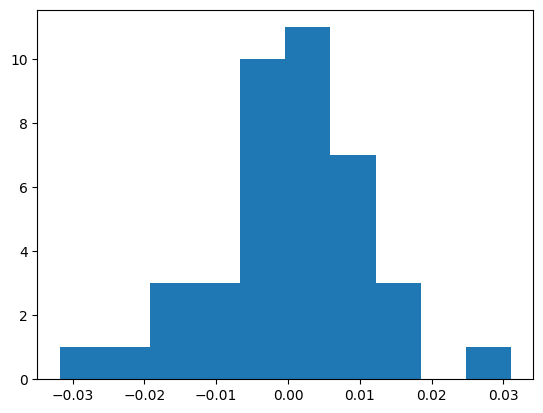

In [33]:
plt.hist((gathered_dist_pred - local_pred).numpy().ravel())

In [34]:
local_pred

<tf.Tensor: shape=(20, 2), dtype=float32, numpy=
array([[ 0.27950144, -0.013477  ],
       [ 0.2764874 , -0.01958094],
       [ 0.27586058, -0.01936262],
       [ 0.27874234, -0.02076519],
       [ 0.27358562, -0.01106185],
       [ 0.27437666, -0.01542364],
       [ 0.26762918, -0.0149042 ],
       [ 0.27238345, -0.01345323],
       [ 0.28611794, -0.01262555],
       [ 0.2880017 , -0.01642841],
       [ 0.28009987, -0.01838814],
       [ 0.28372172, -0.01782243],
       [ 0.28036186, -0.02844926],
       [ 0.27698112, -0.03478295],
       [ 0.27655765, -0.0347638 ],
       [ 0.2795071 , -0.03548445],
       [ 0.27858263,  0.00158219],
       [ 0.275991  , -0.00441113],
       [ 0.27504504, -0.00373242],
       [ 0.27788547, -0.00560067]], dtype=float32)>

In [35]:
local_loss_function(gathered_dist_pred)

<tf.Tensor: shape=(), dtype=float32, numpy=55.803043>